# Task 1: character GPT on TinyStories

Trained from scratch. Hand-written causal attention, pre-norm blocks, no `nn.Transformer`.
Full run is `python task1_llm/ayush/src/train.py --config configs/ayush/base.yaml` on COLAB_GPU (NVIDIA RTX PRO 6000 Blackwell). This notebook loads that checkpoint and the saved metrics.

In [1]:
from pathlib import Path
import torch
from task1_llm.ayush.src.model import CharGPT, count_parameters

root = Path(".").resolve()
if not (root / "task1_llm").exists():
    root = Path(__file__).resolve().parents[3] if "__file__" in dir() else Path.cwd()
ckpt_path = root / "task1_llm/ayush/checkpoints/chargpt_best.pt"
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
cfg = ckpt["config"]
model = CharGPT(vocab_size=len(ckpt["stoi"]), **cfg)
model.load_state_dict(ckpt["model"])
print("epoch", ckpt["epoch"], "val_loss", round(ckpt["val_loss"], 4))
print("params", count_parameters(model))
print("vocab", len(ckpt["stoi"]), "block", cfg["block_size"], "layers", cfg["n_layer"], "heads", cfg["n_head"])
print("tied", model.head.weight.data_ptr() == model.tok_emb.weight.data_ptr())


epoch 29 val_loss 0.7526
params 3248640
vocab 108 block 256 layers 4 heads 4
tied True


In [2]:
print(open(root / "task1_llm/ayush/metrics_report.csv").read())

train_ce,val_ce,perplexity,bits_per_char,generalization_gap,top1_acc,distinct_1,distinct_2,distinct_3,rep_4gram,grad_norm_max,grad_norm_median,grad_spikes,grad_nans,param_count,tokens_per_sec,gen_tokens_per_sec,peak_mem_gb,train_time_sec,epochs,train_stories,val_stories,vocab_size,smoke,train_ce_epoch30,val_ce_epoch30,best_epoch,best_val_ce
0.8098889851035216,0.7513776874542236,2.119918590956155,1.084008863524826,-0.058511297649297966,0.76346484375,0.005575117370892019,0.047236377891023126,0.16437549096622153,0.8233963006690279,7.17718505859375,0.5947554111480713,0,0,3248640,844936.3097821577,1354.773130957496,1.91343104,181.49798774719238,30,100000,10000,108,0,0.8099,0.7584,29,0.7526


Loss curve from the same run (`outputs/loss_curves.png`). Train is the epoch average, val is a pass over 2,000 windows from the 10,000-story val split.

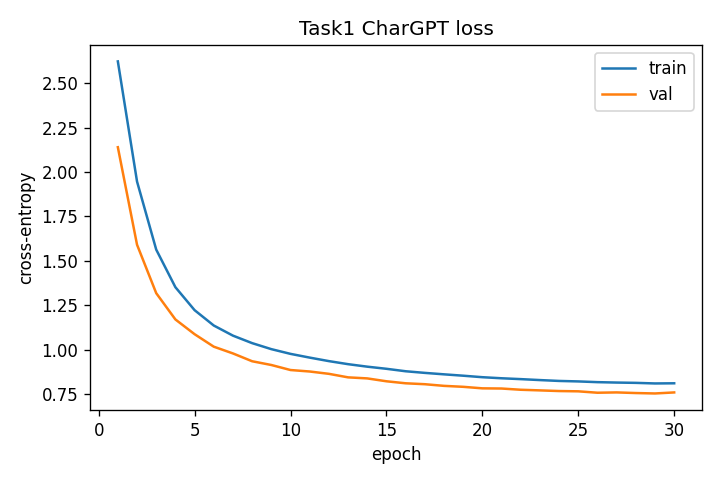

--- three of the 20 samples ---
Once upon a time, there was a princess named Daisy. Daisy loved to explore the colors and ran over to do it. He would stay in his way until he finally wanted to help her.

One day, Daisy saw a little girl named Lily who wanted to go to the tree, so she ran outside and took a walk in the sky. 

She was three years old and saw a big tree. She said, "Hello, little girl is so sad. But I don't mean to pick it up". 

As she got a angel and charming down as her mum at it, she thought she was so cool. She asked if she 

----

One day, a little girl named Lily went to the fridge. She was happy and wanted to play. She wanted to find her friends to play with Spot and Lily. They put their toy car in the nearby house.

The girl and the sun were having so much fun. They got an important day, and they were on the floor to go see their cars. They could show their friends and both them to play.

But their mom said no. She said they were the best of friends. They were not

In [3]:
from IPython.display import Image, display
display(Image(filename=str(root / "task1_llm/ayush/outputs/loss_curves.png")))
print("--- three of the 20 samples ---")
text = (root / "task1_llm/ayush/outputs/generations.txt").read_text()
print("\n\n----\n\n".join(text.split("\n\n----\n\n")[:3]))


Failure cases and the full metric table are in `results.md` and `failure_analysis.md` next to this notebook.